In [2]:
from datetime import datetime, timedelta, time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pm4py
import os

### Question 1: Initial Overview

In [3]:
# Load the event log used throughout Question 1
log = pm4py.read_xes("Event Logs/all.xes")
log.head(3)

C:\Users\henri\anaconda3\Lib\site-packages\pm4py\utils.py:1000: UserWarning: Install the optional requirement `rustxes` to import/export files faster.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/1820 [00:00<?, ?it/s]

,concept:name,time:timestamp,org:resource,lifecycle:transition,case:concept:name,case:customer_id,case:customer_name,case:customer_ssid,case:loan_amount,case:case_creation_no,...,loan_decision,loan_decision_extra,interest,loan_term_years,recipient,transfer_amount,repayments,installment_target,repaid_amount,cumulatively_repaid
0,Application Registered,2021-01-03 09:04:01+00:00,System Resource,complete,470-16,470,Customer 470,6c710e01-8262-41dd-8476-688b1513d23c,500.0,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Retrieve Identity Document,2021-01-03 09:04:02+00:00,System Resource,complete,470-16,470,Customer 470,6c710e01-8262-41dd-8476-688b1513d23c,500.0,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Retrieve Internal Log Data,2021-01-03 10:12:01+00:00,Risk Assessment System,complete,470-16,470,Customer 470,6c710e01-8262-41dd-8476-688b1513d23c,500.0,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**(a) Cases, events, unique activities, and timeframe**


In [3]:
n_cases      = log["case:concept:name"].nunique()
n_events     = len(log)
n_activities = log["concept:name"].nunique()
t_min, t_max = log["time:timestamp"].min(), log["time:timestamp"].max()
duration     = t_max - t_min

print(f"# cases             : {n_cases}")
print(f"# events            : {n_events}")
print(f"# unique activities : {n_activities}")
print(f"timeframe           : {t_min}  ->  {t_max}")
print(f"duration            : {duration}")

# cases             : 1820
# events            : 47553
# unique activities : 26
timeframe           : 2021-01-01 00:00:01+00:00  ->  2023-09-13 09:00:03+00:00
duration            : 985 days 09:00:02


**Answer (a):** The log contains **1 820 cases**, **47 553 events**, and **26 unique activities**.
It spans the period **2021-01-01 to 2023-09-13**, covering **985 days (≈2 years 8 months)**.


**(b) Number of variants and average events per case**


In [4]:
variants = pm4py.get_variants(log)
n_variants = len(variants)
avg_events = log.groupby("case:concept:name").size().mean()

print(f"# variants           : {n_variants}")
print(f"avg events per case  : {avg_events:.2f}")

# variants           : 678
avg events per case  : 26.13


**Answer (b):** The log contains **678 variants**.
The average number of events per case is **≈ 26.13 events**.

**(c) Event attributes vs. case attributes, and event-attribute -> activity mapping**


In [5]:
case_attributes  = [c for c in log.columns if c.startswith("case:")]
event_attributes = [c for c in log.columns if not c.startswith("case:")]

print("Case attributes:")
for c in case_attributes:
    print("  -", c)

print("\nEvent attributes:")
for e in event_attributes:
    print("  -", e)

# Domain-specific event attributes (i.e. excluding the standard XES ones) and the activities at which they actually carry a value.
standard = {"concept:name", "time:timestamp", "org:resource", "lifecycle:transition"}
domain_attributes = [d for d in event_attributes if d not in standard]

print("\nEvent attribute -> activities at which it is recorded:")
for col in domain_attributes:
    acts = sorted(log.loc[log[col].notna(), "concept:name"].unique())
    print(f"  {col:32s} -> {acts}")

Case attributes:
  - case:concept:name
  - case:customer_id
  - case:customer_name
  - case:customer_ssid
  - case:loan_amount
  - case:case_creation_no

Event attributes:
  - concept:name
  - time:timestamp
  - org:resource
  - lifecycle:transition
  - prior_defaults
  - prior_applications
  - auto_id_verification_outcome
  - risk_score
  - credit_score
  - code
  - manual_id_verification_outcome
  - loan_decision
  - loan_decision_extra
  - interest
  - loan_term_years
  - recipient
  - transfer_amount
  - repayments
  - installment_target
  - repaid_amount
  - cumulatively_repaid

Event attribute -> activities at which it is recorded:
  prior_defaults                   -> ['Create Assessment Report', 'Retrieve Internal Log Data']
  prior_applications               -> ['Create Assessment Report', 'Retrieve Internal Log Data']
  auto_id_verification_outcome     -> ['Verify ID Automatically']
  risk_score                       -> ['Create Assessment Report', 'Retrieve Customer Global R

**Answer (c):**

*Case attributes* (constant per case):
`case:concept:name`, `case:customer_id`, `case:customer_name`, `case:customer_ssid`,
`case:loan_amount`, `case:case_creation_no`.

*Event attributes* fall into two groups.
**Standard XES attributes** (recorded for every event):
`concept:name`, `time:timestamp`, `org:resource`, `lifecycle:transition`.
**Domain-specific event attributes** are produced only by the activity that creates them:

| Event attribute | Recorded by activity / activities |
|---|---|
| `auto_id_verification_outcome` | Verify ID Automatically |
| `manual_id_verification_outcome` | Verify ID Manually |
| `risk_score` | Retrieve Customer Global Risk Score, Create Assessment Report |
| `credit_score` | Retrieve Financial Status, Create Assessment Report |
| `prior_defaults` | Retrieve Internal Log Data, Create Assessment Report |
| `prior_applications` | Retrieve Internal Log Data, Create Assessment Report |
| `code` | Reject Application |
| `loan_decision` | Decide Loan Application |
| `loan_decision_extra` | Decide Loan Application |
| `interest` | Received Terms Acceptance |
| `loan_term_years` | Received Terms Acceptance |
| `recipient` | Transfer Funds |
| `transfer_amount` | Transfer Funds |
| `repayments` | Start Repayments |
| `installment_target` | Start Repayments |
| `repaid_amount` | Installment Received |
| `cumulatively_repaid` | Installment Received |

**(d) Frequency distribution of variants**


top-1 variant covers   : 80 cases (4.4%)
top-5 variants cover   : 319 cases (17.5%)
top-10 variants cover  : 528 cases (29.0%)
singleton variants     : 472 of 678 (69.6%)


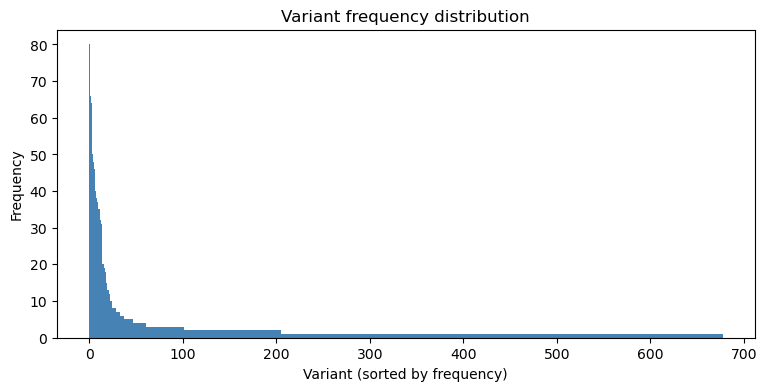

In [7]:
freqs = sorted(pm4py.get_variants(log).values(), reverse=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(freqs)), freqs, color="steelblue", width=1.0)
ax.set_xlabel("Variant (sorted by frequency)")
ax.set_ylabel("Frequency")
ax.set_title("Variant frequency distribution")

n_singleton = sum(f == 1 for f in freqs)
print(f"top-1 variant covers   : {freqs[0]} cases ({100*freqs[0]/sum(freqs):.1f}%)")
print(f"top-5 variants cover   : {sum(freqs[:5])} cases ({100*sum(freqs[:5])/sum(freqs):.1f}%)")
print(f"top-10 variants cover  : {sum(freqs[:10])} cases ({100*sum(freqs[:10])/sum(freqs):.1f}%)")
print(f"singleton variants     : {n_singleton} of {len(freqs)} ({100*n_singleton/len(freqs):.1f}%)")

**Answer (d):** Only a few variants occur often, and most variants occur very rarely: the most frequent variant only covers 80 cases (≈4.4 % of all cases), the top-10 variants together cover only ≈29 % of the cases, and ≈70 % of all variants (472 of 678) occur in just one single case. There is no clear main path through the process, and we see a lot of different behaviour. Process discovery algorithms will probably have a hard time with this.

**(e) Distribution of case durations**


min    : 0 days 06:06:02
max    : 758 days 10:28:02
mean   : 292 days 01:14:30.405494504
median : 220 days 20:38:04
std    : 220 days 18:18:33.765425954


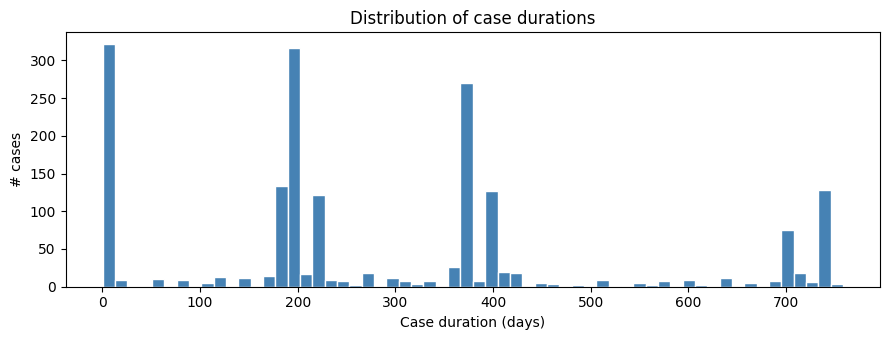

In [7]:
durations = (log.groupby("case:concept:name")["time:timestamp"]
                  .agg(lambda s: s.max() - s.min()))
secs = durations.dt.total_seconds()

print(f"min    : {durations.min()}")
print(f"max    : {durations.max()}")
print(f"mean   : {pd.to_timedelta(secs.mean(), unit='s')}")
print(f"median : {durations.median()}")
print(f"std    : {pd.to_timedelta(secs.std(),  unit='s')}")

plt.figure(figsize=(9, 3.5))
plt.hist(secs / 86400, bins=60, color="steelblue", edgecolor="white")
plt.xlabel("Case duration (days)")
plt.ylabel("# cases")
plt.title("Distribution of case durations")
plt.tight_layout(); plt.show()


**Answer (e):** Case durations go from **≈6 hours** up to **≈758 days**, with a **mean of ≈292 days**, a **median of ≈221 days**, and a **standard deviation of ≈221 days**. The mean is clearly higher than the median and the standard deviation is about as big as the mean, so most cases are short and a few are very long. The histogram shows four clear groups: a lot of very short cases (≈0 days, probably applications that get rejected right after the credit check) and three peaks around ≈½, ≈1 and ≈2 years. These three peaks match exactly the three values we see in loan_term_years (0.5, 1.0, 2.0). So the log clearly contains different types of cases mixed together (rejected ones vs. accepted-and-repaid ones, and within the accepted ones, three different loan terms). This is a good reason to look at them separately later.

### Question 2: General Visual Analytics & Exploration

**(a) Variant Analysis – select 5 variants and report their frequencies**


In [9]:
# Sort variants by frequency (descending)
variants = pm4py.get_variants(log)
sorted_variants = sorted(variants.items(), key=lambda x: -x[1])

# V1: most frequent variant (happy path)
v1 = sorted_variants[0][0]

# V2: most frequent variant ending in "Repayment Completed" that is longer than V1
v2 = next(v for v, c in sorted_variants
          if v[-1] == "Repayment Completed" and len(v) > len(v1))

# V3: most frequent rejected variant that contains "Decide Loan Application"
v3 = next(v for v, c in sorted_variants
          if v[-1] == "Send Rejection Notification" and "Decide Loan Application" in v)

# V4: most frequent rejected variant WITHOUT "Decide Loan Application" (auto-rejection)
v4 = next(v for v, c in sorted_variants
          if v[-1] == "Send Rejection Notification" and "Decide Loan Application" not in v)

# V5: most frequent variant ending in "Send to Collections" (defaulted loan)
v5 = next(v for v, c in sorted_variants if v[-1] == "Send to Collections")

selected = {
    "V1 (happy path, 6 installments)":   v1,
    "V2 (happy path, 12 installments)":  v2,
    "V3 (rejected AFTER Decide)":        v3,
    "V4 (rejected BEFORE Decide)":       v4,
    "V5 (default - Send to Coll.)":      v5,
}

print(f"# variants in log: {len(variants)}\n")
for label, v in selected.items():
    print(f"{label}: freq = {variants[v]:3d}, length = {len(v):2d}")

# variants in log: 678

V1 (happy path, 6 installments): freq =  80, length = 23
V2 (happy path, 12 installments): freq =  50, length = 29
V3 (rejected AFTER Decide): freq =  38, length = 13
V4 (rejected BEFORE Decide): freq =  20, length = 11
V5 (default - Send to Coll.): freq =   3, length = 28


In [10]:
# Print the activity sequences of the five selected variants
for label, v in selected.items():
    print(f"\n=== {label}  (freq={variants[v]}, length={len(v)}) ===")
    for i, a in enumerate(v, 1):
        print(f"  {i:2d}. {a}")


=== V1 (happy path, 6 installments)  (freq=80, length=23) ===
   1. Application Registered
   2. Retrieve Identity Document
   3. Retrieve Internal Log Data
   4. Verify ID Automatically
   5. Confirmed Identity
   6. Query Central Bank System
   7. Query Credit Bureau
   8. Retrieve Customer Global Risk Score
   9. Retrieve Financial Status
  10. Create Assessment Report
  11. Decide Loan Application
  12. Send Acceptance Confirmation
  13. Accept Terms
  14. Received Terms Acceptance
  15. Transfer Funds
  16. Start Repayments
  17. Installment Received
  18. Installment Received
  19. Installment Received
  20. Installment Received
  21. Installment Received
  22. Installment Received
  23. Repayment Completed

=== V2 (happy path, 12 installments)  (freq=50, length=29) ===
   1. Application Registered
   2. Retrieve Identity Document
   3. Retrieve Internal Log Data
   4. Verify ID Automatically
   5. Confirmed Identity
   6. Query Central Bank System
   7. Retrieve Customer Global

**Annotated visualization of variant V1 (the happy path)**


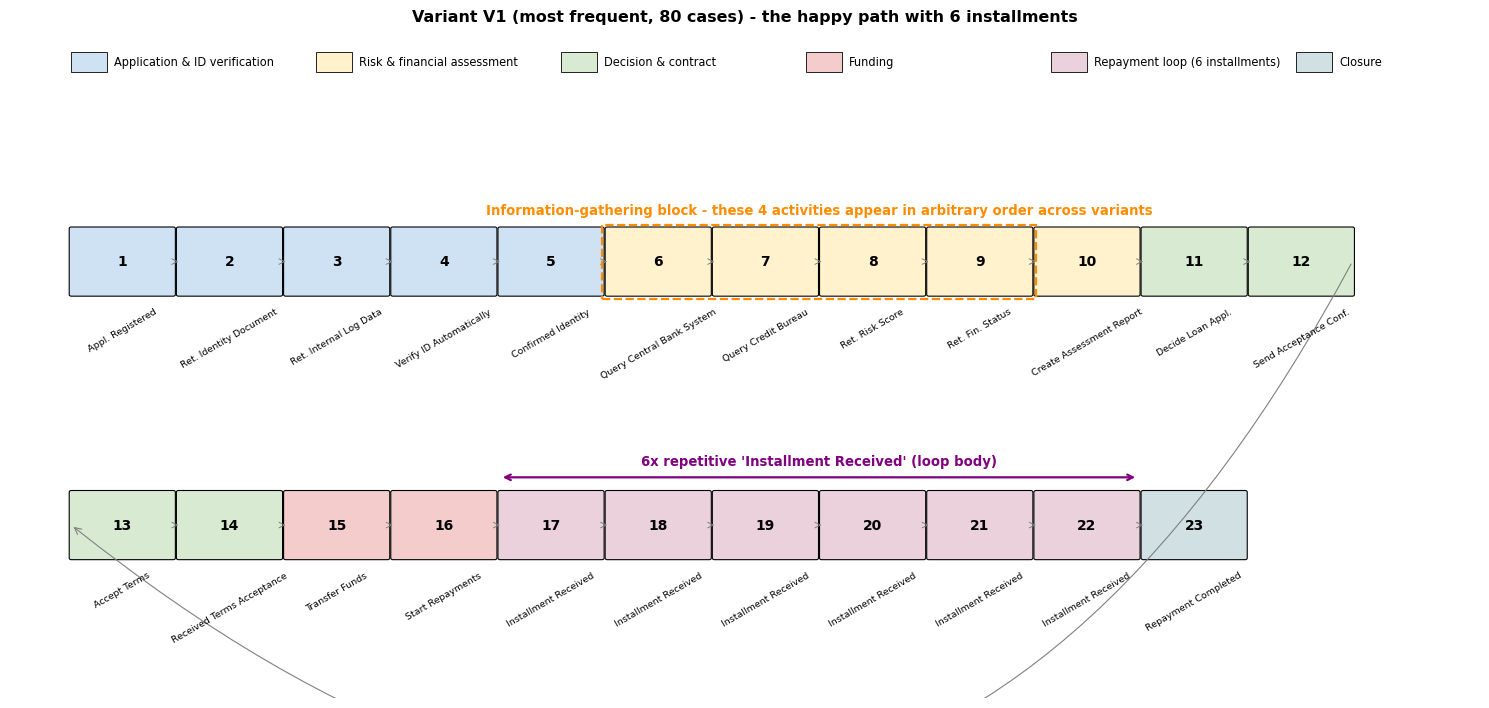

In [11]:
# Annotated visualization of V1 - we highlight the two patterns that recur across many other variants of the log:
#   * the 4-activity 'information-gathering block', whose internal order is interchangeable across variants (compare V1, V2, V3, V4)
#   * the repetitive 'Installment Received' loop body (whose length encodes the loan term: 6 installments = 0.5y, 12 = 1y, 24 = 2y)

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle

variant_v1 = selected["V1 (happy path, 6 installments)"]

phases = [
    ("Application & ID verification",   range(0,5),   "#cfe2f3"),
    ("Risk & financial assessment",     range(5,10),  "#fff2cc"),
    ("Decision & contract",             range(10,14), "#d9ead3"),
    ("Funding",                         range(14,16), "#f4cccc"),
    ("Repayment loop (6 installments)",  range(16,22), "#ead1dc"),
    ("Closure",                         range(22,23), "#d0e0e3"),
]

fig, ax = plt.subplots(figsize=(15, 7.2))
ax.set_xlim(-0.2, 14.2); ax.set_ylim(-0.2, 8); ax.axis("off")

box_w, box_h, per_row = 1.0, 0.8, 12
y_top, y_bot = 4.7, 1.5
positions = [(0.4 + (i % per_row)*1.05, y_top if i < per_row else y_bot)
             for i in range(len(variant_v1))]
color_of = {i: c for label, idx_range, c in phases for i in idx_range}

for i, (x, y) in enumerate(positions):
    ax.add_patch(FancyBboxPatch((x, y), box_w, box_h, boxstyle="round,pad=0.02",
                                 linewidth=0.8, facecolor=color_of[i],
                                 edgecolor="black"))
    ax.text(x + box_w/2, y + box_h/2, str(i+1),
            ha="center", va="center", fontsize=10, weight="bold")
    short = (variant_v1[i].replace("Retrieve ", "Ret. ")
                          .replace("Application", "Appl.")
                          .replace("Confirmation", "Conf.")
                          .replace("Customer Global ", "")
                          .replace("Financial Status", "Fin. Status"))
    ax.text(x + box_w/2, y - 0.15, short,
            ha="center", va="top", fontsize=6.8, rotation=30)

# horizontal arrows within rows
for i in range(len(variant_v1) - 1):
    if i == per_row - 1:
        continue
    (x1, y1), (x2, y2) = positions[i], positions[i+1]
    ax.add_patch(FancyArrowPatch((x1+box_w, y1+box_h/2), (x2, y2+box_h/2),
                  arrowstyle="->", mutation_scale=10, color="grey", lw=0.7))

# row-wrap arrow
(x1, y1) = positions[per_row-1]; (x2, y2) = positions[per_row]
ax.add_patch(FancyArrowPatch((x1+box_w, y1+box_h/2), (x2, y2+box_h/2),
              arrowstyle="->", mutation_scale=12, color="grey", lw=0.8,
              connectionstyle="arc3,rad=-0.6"))

# annotation: 6x repetitive installment loop
inst_idx = list(range(16, 22))
xs = [positions[i][0] for i in inst_idx]
y_lab = positions[inst_idx[0]][1] + box_h + 0.18
ax.annotate("", xy=(xs[-1] + box_w, y_lab), xytext=(xs[0], y_lab),
            arrowprops=dict(arrowstyle="<->", color="purple", lw=1.6))
ax.text((xs[0] + xs[-1] + box_w)/2, y_lab + 0.15,
        "6x repetitive 'Installment Received' (loop body)",
        ha="center", color="purple", fontsize=9.5, weight="bold")

# annotation: information-gathering block
info_idx = list(range(5, 9))
xs2 = [positions[i][0] for i in info_idx]
y_box_top = positions[info_idx[0]][1] + box_h
ax.add_patch(Rectangle((xs2[0]-0.05, positions[info_idx[0]][1]-0.05),
                        xs2[-1]+box_w-xs2[0]+0.1, box_h+0.10,
                        fill=False, edgecolor="darkorange", lw=1.6, ls="--"))
ax.text((xs2[0] + xs2[-1] + box_w)/2, y_box_top + 0.18,
        "Information-gathering block - these 4 activities appear in arbitrary order across variants",
        ha="center", color="darkorange", fontsize=9.5, weight="bold")

# legend
y_leg = 7.4
for k, (label, _, col) in enumerate(phases):
    x_l = 0.4 + k * 2.4
    ax.add_patch(Rectangle((x_l, y_leg), 0.35, 0.25,
                  facecolor=col, edgecolor="black", lw=0.6))
    ax.text(x_l + 0.42, y_leg + 0.12, label, va="center", fontsize=8.2)

ax.set_title("Variant V1 (most frequent, 80 cases) - the happy path with 6 installments",
             fontsize=11.5, weight="bold", y=0.99)
plt.tight_layout(); plt.show()

**Comparison of the 5 selected variants (activities, length, attributes)**


In [12]:
# Build a comparison table along: contained activities, length, and the domain-specific attributes that are populated in an example case of each variant.

attr_cols = ['risk_score','credit_score','code','loan_decision',
             'auto_id_verification_outcome','manual_id_verification_outcome',
             'transfer_amount','interest','loan_term_years','repaid_amount']

case_act_seq = (log.sort_values("time:timestamp")
                   .groupby("case:concept:name")["concept:name"]
                   .apply(tuple))

rows = []
for label, v in selected.items():
    cases = case_act_seq[case_act_seq == v].index.tolist()
    cid = cases[0]
    sub = log[log["case:concept:name"] == cid]
    dur = sub["time:timestamp"].max() - sub["time:timestamp"].min()
    populated = {col: sub.loc[sub[col].notna(), col].astype(str).unique().tolist()
                 for col in attr_cols if sub[col].notna().any()}
    rows.append({
        "variant": label,
        "freq":    variants[v],
        "length":  len(v),
        "# distinct activities": len(set(v)),
        "example case":         cid,
        "example duration":     str(dur),
        "populated attributes": populated,
    })

cmp_df = pd.DataFrame(rows)
print(cmp_df[["variant","freq","length","# distinct activities",
              "example case","example duration"]].to_string(index=False))

print("\nPopulated domain-specific attributes (one example case per variant):")
for r in rows:
    print(f"\n{r['variant']}  (case {r['example case']}):")
    for k, vals in r["populated attributes"].items():
        print(f"   {k:32s} -> {vals}")


                         variant  freq  length  # distinct activities example case  example duration
 V1 (happy path, 6 installments)    80      23                     18     101-1919 189 days 16:29:08
V2 (happy path, 12 installments)    50      29                     18      101-465 372 days 08:42:05
      V3 (rejected AFTER Decide)    38      13                     13     147-1907   0 days 17:05:02
     V4 (rejected BEFORE Decide)    20      11                     11     195-1320   0 days 23:05:01
    V5 (default - Send to Coll.)     3      28                     22     271-1224 270 days 17:16:07

Populated domain-specific attributes (one example case per variant):

V1 (happy path, 6 installments)  (case 101-1919):
   risk_score                       -> ['0.17']
   credit_score                     -> ['828.37']
   loan_decision                    -> ['accept']
   auto_id_verification_outcome     -> ['valid']
   transfer_amount                  -> ['500.0']
   interest                

**Answer (a):** The five variants have very different lengths (11–29 events) but reuse the same building blocks:

* **Contained activities.** All five start with the same five activities (application registration and ID verification), then go through the same four information-gathering activities. They differ in what happens after that: V1 and V2 go through the contract, funding and repayment phases and end with `Repayment Completed`; V3 follows the manual rejection branch (`Decide Loan Application` → `Reject Application` → `Send Rejection Notification`); V4 is auto-rejected and *skips* `Decide Loan Application` entirely; V5 is accepted at first but the customer stops paying, so the case ends in the collections branch (`Loan Default Notice Received` → `Formally Initiate Debt Recovery` → `Send to Collections`).
* **Length.** The length depends mostly on the number of `Installment Received` events: 6 in V1, 12 in V2, around 3–4 in V5, and 0 in the rejection variants V3 and V4.
* **Attributes.** V1 and V2 have all the attributes you would expect for an accepted loan (`loan_decision = accept`, `interest`, `loan_term_years`, `transfer_amount`, `repaid_amount`); V3 has `loan_decision = reject` and a rejection `code` (here MLA); V4 has only the rejection `code` (here LCS) but **no** `loan_decision`, because `Decide Loan Application` was skipped. V5 has the same attributes as V1 and V2, but no `Repayment Completed` at the end. The two rejection variants also have very different `risk_score` values (0.32 vs. 0.69), which fits with the fact that a very high risk score leads to auto-rejection without a manual decision. Another thing we noticed: V1 (case `101-1919`) and V2 (case `101-465`) belong to the **same customer** (`101`) – customers can therefore have several loans over time.

**(b) Frequency-annotated Directly-Follows Graph (DFG)**


# DFG edges       : 81
# start activities: 1 -> {'Application Registered': 1820}
# end activities  : 3   -> {'Send Rejection Notification': 321, 'Send to Collections': 318, 'Repayment Completed': 1181}

Top 10 directly-follows relations:
  13990   Installment Received  ->  Installment Received
   1820   Application Registered  ->  Retrieve Identity Document
   1671   Create Assessment Report  ->  Decide Loan Application
   1499   Accept Terms  ->  Received Terms Acceptance
   1499   Decide Loan Application  ->  Send Acceptance Confirmation
   1499   Received Terms Acceptance  ->  Transfer Funds
   1499   Send Acceptance Confirmation  ->  Accept Terms
   1499   Transfer Funds  ->  Start Repayments
   1468   Verify ID Automatically  ->  Confirmed Identity
   1419   Start Repayments  ->  Installment Received


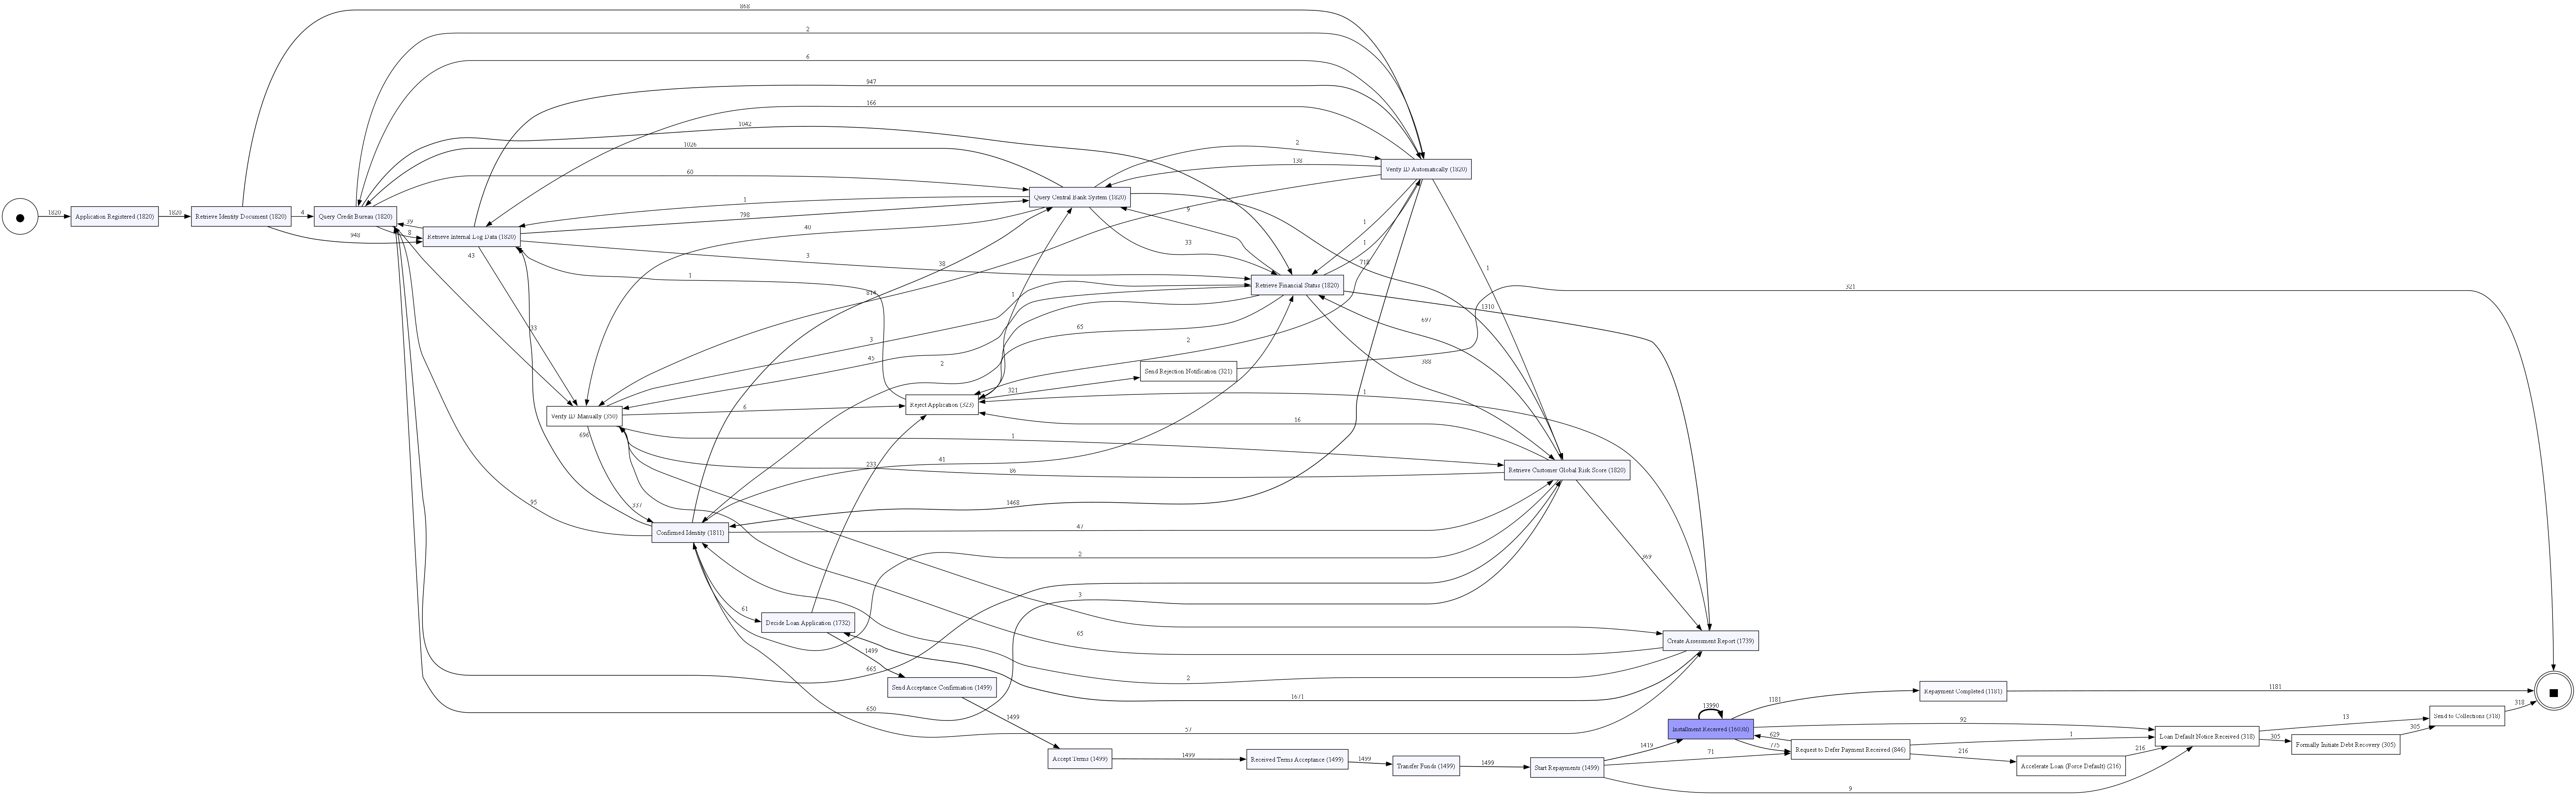

In [13]:
dfg, start_acts, end_acts = pm4py.discover_directly_follows_graph(log)

print(f"# DFG edges       : {len(dfg)}")
print(f"# start activities: {len(start_acts)} -> {dict(start_acts)}")
print(f"# end activities  : {len(end_acts)}   -> {dict(end_acts)}")
print(f"\nTop 10 directly-follows relations:")
for (a, b), c in sorted(dfg.items(), key=lambda kv: -kv[1])[:10]:
    print(f"  {c:5d}   {a}  ->  {b}")

# Render the DFG inline in the notebook and save to directory
from IPython.display import Image
pm4py.save_vis_dfg(dfg, start_acts, end_acts, "dfg_all.png")
Image("dfg_all.png")

**Answer (b):** The DFG has one start activity (`Application Registered`, all 1 820 cases) and three end activities for the three possible outcomes: `Repayment Completed` (1 181), `Send Rejection Notification` (321) and `Send to Collections` (318), so about 65 % of loans are repaid, 18 % are rejected up front and 17 % default after acceptance. The strongest edge by far is the `Installment Received` self-loop with 13 990 occurrences (about 30 % of all events), followed by the fixed sequence `Decide Loan Application → Send Acceptance Confirmation → Accept Terms → Received Terms Acceptance → Transfer Funds → Start Repayments` with around 1 499 occurrences each, which is the standard contract and funding part of the process. The four information-gathering activities (`Query Central Bank System`, `Query Credit Bureau`, `Retrieve Customer Global Risk Score`, `Retrieve Financial Status`), in contrast, are connected to each other in many directions, which means they can run in parallel — this matches what we already saw in (a), where their order was different in different variants, and explains why we have so many different variants. Finally, the edge `Verify ID Automatically → Verify ID Manually` shows that there is a fallback path: when automatic ID verification doesn't work, a manual check is done instead, which is also why 243 variants contain `Verify ID Manually`.

### Question 3: Use Case-Specific Visual Analytics & Exploration

### Question 4: Process Discovery

### Question 5: Conformance Checking

**(a) Load and visualize the two Petri nets**


In [14]:
# Load both Petri nets
pn_ind,  im_ind,  fm_ind = pm4py.read_pnml("Input Process Models/pn-loan-inductive.pnml")
pn_hand, im_hand, fm_hand = pm4py.read_pnml("Input Process Models/pn-loan-handmade.pnml")

def describe(name, pn):
    visible = [t for t in pn.transitions if t.label is not None]
    silent = [t for t in pn.transitions if t.label is None]
    from collections import Counter
    dup = {l:c for l,c in Counter(t.label for t in visible).items() if c > 1}
    print(f"{name:25s}  places={len(pn.places):3d}  transitions={len(pn.transitions):3d}"
          f"  (visible={len(visible)}, silent={len(silent)})  arcs={len(pn.arcs):3d}")
    if dup:
        print(f"   duplicate labels: {dup}")

describe("pn_loan_inductive", pn_ind)
describe("pn_loan_handmade",  pn_hand)

pn_loan_inductive          places= 36  transitions= 39  (visible=26, silent=13)  arcs= 90
pn_loan_handmade           places= 27  transitions= 32  (visible=29, silent=3)  arcs= 69
   duplicate labels: {'Confirmed Identity': 2, 'Reject Application': 3}


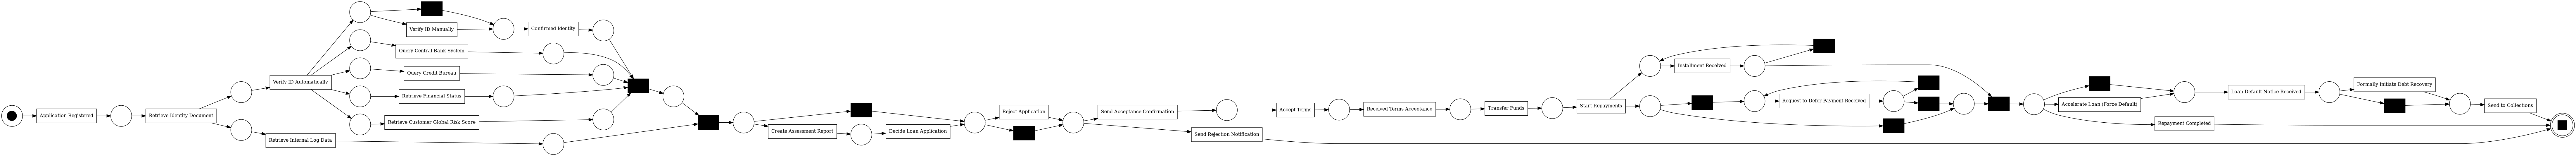

In [14]:
# Visualize the inductive Petri net (rendered inline) and save to directory
from IPython.display import Image
pm4py.save_vis_petri_net(pn_ind, im_ind, fm_ind, "pn_inductive.png")
Image("pn_inductive.png")


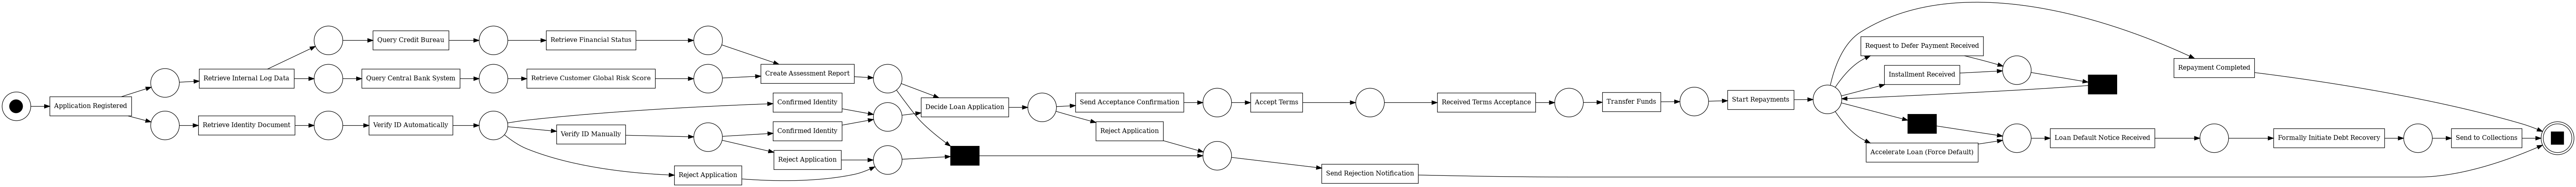

In [15]:
# Visualize the handmade Petri net (rendered inline) and save to directory
pm4py.save_vis_petri_net(pn_hand, im_hand, fm_hand, "pn_handmade.png")
Image("pn_handmade.png")


**Answer (a):** Both nets use the same 26 activity labels but look very different. The inductive model has 36 places and 39 transitions (26 visible + 13 silent), and every label only appears once — the silent transitions are used to model skips and loops, which is typical for the Inductive Miner. The handmade model is smaller (27 places, 32 transitions, only 3 silent), but it uses duplicate labels: `Reject Application` appears **3 times** (once for each rejection point in the process) and `Confirmed Identity` appears **2 times** (once after the automatic and once after the manual ID check). So the handmade model shows the different cases directly with duplicate transitions, while the inductive model uses silent transitions and routing places instead.

**(b) Token-based fitness, alignment-based fitness and alignment-based precision on `all.xes`**


In [15]:
def evaluate(name, pn, im, fm):
    tb_fit = pm4py.fitness_token_based_replay(log, pn, im, fm)
    al_fit = pm4py.fitness_alignments(log,    pn, im, fm)
    al_prec = pm4py.precision_alignments(log,  pn, im, fm)
    print(f"\n=== {name} ===")
    print(f"  token-based fitness     : log_fitness  = {tb_fit['log_fitness']:.4f},"
          f"  perc_fit_traces = {tb_fit['perc_fit_traces']:.2f}%")
    print(f"  alignment-based fitness : log_fitness  = {al_fit['log_fitness']:.4f},"
          f"  perc_fit_traces = {al_fit['percentage_of_fitting_traces']:.2f}%")
    print(f"  alignment-based precision: {al_prec:.4f}")
    return {"tb": tb_fit['log_fitness'], "al": al_fit['log_fitness'],
            "fit_traces": al_fit['percentage_of_fitting_traces'], "prec": al_prec}

scores_ind = evaluate("pn_loan_inductive", pn_ind,  im_ind,  fm_ind)
scores_hand = evaluate("pn_loan_handmade",  pn_hand, im_hand, fm_hand)

replaying log with TBR, completed traces ::   0%|          | 0/678 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/678 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/4984 [00:00<?, ?it/s]


=== pn_loan_inductive ===
  token-based fitness     : log_fitness  = 0.9967,  perc_fit_traces = 95.22%
  alignment-based fitness : log_fitness  = 0.9974,  perc_fit_traces = 95.22%
  alignment-based precision: 0.7311


replaying log with TBR, completed traces ::   0%|          | 0/678 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/678 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/4984 [00:00<?, ?it/s]


=== pn_loan_handmade ===
  token-based fitness     : log_fitness  = 0.9974,  perc_fit_traces = 94.29%
  alignment-based fitness : log_fitness  = 0.9971,  perc_fit_traces = 94.29%
  alignment-based precision: 0.5827


**Answer (b):** Both models replay `all.xes` very well in terms of fitness, but differ in precision.

| Metric | `pn_loan_inductive` | `pn_loan_handmade` |
|---|---|---|
| Token-based fitness (`log_fitness`) | **0.9967** | **0.9974** |
| Alignment-based fitness (`log_fitness`) | **0.9974** | **0.9971** |
| % perfectly fitting traces | **95.22 %** | **94.29 %** |
| Alignment-based precision | **0.7311** | **0.5827** |

**(c) Soundness of `pn_loan_handmade`**


In [17]:
# Run the soundness check on the handmade net
sound_ok, diag = pm4py.check_soundness(pn_hand, im_hand, fm_hand)
print(f"is_sound = {sound_ok}")
print("Diagnostic messages:")
from pm4py.algo.analysis.woflan.algorithm import Outputs
for m in diag[Outputs.DIAGNOSTIC_MESSAGES]:
    print(" -", m)

is_sound = True
Diagnostic messages:
 - Input is ok.
 - Petri Net is a workflow net.
 - Every place is covered by s-components.
 - There are no dead tasks.
 - All tasks are live.


/tmp/ipykernel_535/1982517082.py:2: DeprecatedWarning: check_soundness is deprecated as of 2.3.0 and will be removed in 3.0.0. this method will be removed in a future release.
  sound_ok, diag = pm4py.check_soundness(pn_hand, im_hand, fm_hand)
/usr/local/lib/python3.12/dist-packages/pm4py/algo/analysis/woflan/place_invariants/utility.py:163: UserWarning: solution from scipy may be unstable. Please install PuLP (pip install pulp) for fully reliable results.
  warnings.warn(


**Answer (c):** `pm4py.check_soundness` returns `True` for `pn_loan_handmade`, so all four properties of (Workflow-net) soundness hold. The diagnostic messages from the soundness check confirm this:

| Property | Holds? | Why? |
|---|---|---|
| **Workflow-net structure** (one start place, one end place, every node lies on a path from start to end) | ✓ | The check tells us *"Petri Net is a workflow net."* |
| **Option to complete** (from every reachable marking we can still reach the final marking `[n25]`) | ✓ | The check tells us *"Every place is covered by s-components."* This means no token can get stuck somewhere, so we can always still reach the final marking. |
| **Proper completion** (when we reach the final marking, no other tokens are left somewhere else) | ✓ | The workflow-net structure together with the s-component coverage make sure that the final marking `[n25]` is the only end state and that it has exactly one token in it. |
| **No dead transitions** (every transition can fire in at least one run) | ✓ | The check tells us *"There are no dead tasks."* and *"All tasks are live."* |

**(d) Which model better represents the actual process?**


**Answer (d):** Both models have very similar fitness (around 0.997), but the `pn_loan_inductive` model fits the *actual* process in `all.xes` better. There are three reasons for this:

- **Scores.** The inductive model has a higher precision (0.7311 vs. 0.5827) and more perfectly fitting traces (95.22 % vs. 94.29 %), and the fitness is basically the same. A higher precision means the model allows less behaviour that we did *not* see in the log, which is what we want when we describe the actual process.
- **Allowed behaviour.** The lower precision of the handmade model comes from how it handles rejections: it has three `Reject Application` transitions next to each other, which means it allows manual rejections that skip the assessment report, and also lets you mix the auto-reject and the manual-reject path in ways that never happen in the data. On the other side, the handmade model does *not* allow some things that we *did* see in Q3, like the auto-rejection of LCS cases without `Decide Loan Application`. We will look at this more closely in (e)–(h).
- **Complexity.** The handmade model has a few less places and transitions than the inductive one (27/32 vs. 36/39), but it has 3 duplicate labels, which makes it harder to read in a complex net than the inductive model where every label only appears once. Together with (a) and (c), this makes the inductive model the better choice for *describing* the actual process. The handmade model is still useful as the *normative* model, which is what we use it for in (e)–(i).

For (e)–(i) the process owner says that `pn_loan_handmade` should be seen as the *normative* model — the model that describes how the process *should* run. We now check how three sub-logs fit this model and look at where they deviate:

- **(e)** `accepted-loans.xes` — cases where the loan was accepted and the money was transferred
- **(g)** `lcs-rejected-customers.xes` — cases of customers that were rejected with the LCS code at some point
- **(h)** `mid-rejected-customers.xes` — cases of customers that were rejected with the MID code at some point

We write a small helper function for this, use it in (e), and then call it again in (g) and (h) on the other two sub-logs.

**(e) Alignments on `accepted-loans.xes` — which activities appear problematic?**


In [16]:
from collections import Counter

def conformance_report(log_path, label, n_examples=2):
    sub_log = pm4py.read_xes(log_path)
    n_cases = sub_log["case:concept:name"].nunique()
    fit = pm4py.fitness_alignments(sub_log, pn_hand, im_hand, fm_hand)
    aligns = pm4py.conformance_diagnostics_alignments(sub_log, pn_hand, im_hand, fm_hand)

    log_moves = Counter()
    model_moves = Counter()
    bad_cases = []

    case_ids = sub_log["case:concept:name"].unique()
    for cid, al in zip(case_ids, aligns):
        is_deviating = False
        for log_lbl, model_lbl in al["alignment"]:
            # visible model move
            if log_lbl == ">>" and model_lbl is not None:
                model_moves[model_lbl] += 1
                is_deviating = True
            # log move
            elif model_lbl == ">>":
                log_moves[log_lbl] += 1
                is_deviating = True
        if is_deviating:
            bad_cases.append((cid, al))

    print(f"\n--- {label} ---")
    print(f"# cases: {n_cases}")
    print(f"alignment log fitness: {fit['log_fitness']:.4f}")
    print(f"% perfectly fitting traces: {fit['percentage_of_fitting_traces']:.2f}%")
    print(f"# non-fitting traces: {len(bad_cases)}")

    print("\nTop activities expected by model but missing in log:")
    for a, c in model_moves.most_common(5):
        print(f"  {a}: {c}")

    print("\nTop activities in log but not allowed by model here:")
    for a, c in log_moves.most_common(5):
        print(f"  {a}: {c}")

    # show a few example alignments
    if bad_cases:
        print("\nExample alignments of non-fitting cases:")
        for cid, al in bad_cases[:n_examples]:
            print(f"\ncase {cid} (fitness {al['fitness']:.3f}):")
            for log_lbl, model_lbl in al["alignment"]:
                # skip silent model moves to keep the output readable
                if log_lbl == ">>" and model_lbl is None:
                    continue
                if log_lbl != ">>" and model_lbl != ">>":
                    marker = "ok"
                elif log_lbl == ">>":
                    marker = "M>"
                else:
                    marker = "L>"
                print(f"  {marker}  log={log_lbl}  model={model_lbl}")

    return {"fit": fit, "log_moves": log_moves, "model_moves": model_moves}


res_acc = conformance_report("Event Logs/accepted-loans.xes",
                             "(e) ACCEPTED-LOANS vs pn_loan_handmade")

parsing log, completed traces ::   0%|          | 0/1499 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/617 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/617 [00:00<?, ?it/s]


--- (e) ACCEPTED-LOANS vs pn_loan_handmade ---
# cases: 1499
alignment log fitness: 0.9995
% perfectly fitting traces: 98.60%
# non-fitting traces: 21

Top activities expected by model but missing in log:
  Formally Initiate Debt Recovery: 13
  Retrieve Internal Log Data: 6
  Query Credit Bureau: 2

Top activities in log but not allowed by model here:
  Retrieve Internal Log Data: 6
  Query Credit Bureau: 2

Example alignments of non-fitting cases:

case 635-446 (fitness 0.950):
  ok  log=Application Registered  model=Application Registered
  ok  log=Retrieve Identity Document  model=Retrieve Identity Document
  L>  log=Query Credit Bureau  model=>>
  ok  log=Retrieve Internal Log Data  model=Retrieve Internal Log Data
  M>  log=>>  model=Query Credit Bureau
  ok  log=Retrieve Financial Status  model=Retrieve Financial Status
  ok  log=Verify ID Automatically  model=Verify ID Automatically
  ok  log=Confirmed Identity  model=Confirmed Identity
  ok  log=Query Central Bank System  mode

**Answer (e):** Almost all accepted loans fit the normative model: alignment log-fitness is **0.9995** and **98.60 %** of the traces fit perfectly. Out of the 21 cases that don't fit, the main problem is `Formally Initiate Debt Recovery` — the model expects this activity, but the log does not have it (most of the model moves are on this activity). A few cases also have small ordering issues with `Retrieve Internal Log Data`, `Query Credit Bureau` and `Query Central Bank System`.

**(f) Manually inspect a few alignments on `accepted-loans.xes` — describe 2 reasons for conformance issues**


**Answer (f):** The two example alignments above show two different reasons for conformance issues:

1. **Formal debt recovery is sometimes skipped on default cases.** When an accepted loan ends up in default, the normative model says it should go `Loan Default Notice Received → Formally Initiate Debt Recovery → Send to Collections`. But in some cases the log goes directly from `Loan Default Notice Received` to `Send to Collections`, so `Formally Initiate Debt Recovery` is missing. This means the collections process is started without the formal debt recovery being recorded.
2. **Information-gathering activities sometimes happen in a different order.** `Retrieve Internal Log Data`, `Query Credit Bureau`, `Query Central Bank System` and `Retrieve Financial Status` can run in parallel (we already saw this in Q2(a) and Q2(b)), but the model has a stricter order than what we see in the log. For example, in one of the cases above `Query Credit Bureau` comes before `Retrieve Internal Log Data`, which gives one log move and one model move for the same activity. This is more of a modelling problem than a real process violation.

**(g) Repeat steps (e) and (f) on `lcs-rejected-customers.xes`**


In [17]:
res_lcs = conformance_report("Event Logs/lcs-rejected-customers.xes",
                              "(g) LCS-REJECTED  vs  pn_loan_handmade")

parsing log, completed traces ::   0%|          | 0/139 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/58 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/58 [00:00<?, ?it/s]


--- (g) LCS-REJECTED  vs  pn_loan_handmade ---
# cases: 139
alignment log fitness: 0.9533
% perfectly fitting traces: 41.01%
# non-fitting traces: 82

Top activities expected by model but missing in log:
  Create Assessment Report: 81
  Decide Loan Application: 79
  Retrieve Internal Log Data: 1

Top activities in log but not allowed by model here:
  Reject Application: 2
  Retrieve Internal Log Data: 1

Example alignments of non-fitting cases:

case 756-74 (fitness 0.913):
  ok  log=Application Registered  model=Application Registered
  ok  log=Retrieve Identity Document  model=Retrieve Identity Document
  ok  log=Verify ID Automatically  model=Verify ID Automatically
  ok  log=Retrieve Internal Log Data  model=Retrieve Internal Log Data
  ok  log=Query Central Bank System  model=Query Central Bank System
  ok  log=Retrieve Customer Global Risk Score  model=Retrieve Customer Global Risk Score
  ok  log=Verify ID Manually  model=Verify ID Manually
  ok  log=Confirmed Identity  model=C

**Answer (g):** The LCS sub-log fits much worse than the accepted loans: alignment fitness drops to **0.9533** and only **41.0 %** of the 139 traces fit perfectly. The biggest deviation is structural: in 81 and 79 cases respectively, `Create Assessment Report` and `Decide Loan Application` are expected by the model but never happen in the log. Looking at the example alignments, this happens whenever a customer is auto-rejected because their risk score is too high: the log goes directly from `Retrieve Financial Status` to `Reject Application` to `Send Rejection Notification`, without doing the assessment report or the manual decision in between. The normative model does *not* allow this short-cut — every rejection path in `pn_loan_handmade` goes through `Decide Loan Application`. This is the same thing we already noticed in Q3(c).

Reasons for the conformance issues:

1. **Auto-rejection skips the manual decision.** The system automatically rejects customers with a very high risk score, but the normative model does not include this path. This is why we see model moves on `Create Assessment Report` and `Decide Loan Application` in so many cases.
2. **`Reject Application` happens at an unexpected position.** A small number of cases (2) trigger `Reject Application` at a point where the normative model does not allow it, which gives a log move. These are probably cases where a previous application of the same customer was already rejected, and the rejection event ended up in the next case. The LCS sub-log contains *all* cases of customers that were ever rejected with LCS, so the same customer can appear with multiple loan attempts.

**(h) Repeat steps (e) and (f) on `mid-rejected-customers.xes`**


In [18]:
res_mid = conformance_report("Event Logs/mid-rejected-customers.xes",
                              "(h) MID-REJECTED  vs  pn_loan_handmade")

parsing log, completed traces ::   0%|          | 0/8 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/6 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/6 [00:00<?, ?it/s]


--- (h) MID-REJECTED  vs  pn_loan_handmade ---
# cases: 8
alignment log fitness: 0.9780
% perfectly fitting traces: 75.00%
# non-fitting traces: 2

Top activities expected by model but missing in log:
  Create Assessment Report: 2

Top activities in log but not allowed by model here:
  Reject Application: 2

Example alignments of non-fitting cases:

case 358-964 (fitness 0.909):
  ok  log=Application Registered  model=Application Registered
  ok  log=Retrieve Identity Document  model=Retrieve Identity Document
  ok  log=Retrieve Internal Log Data  model=Retrieve Internal Log Data
  ok  log=Verify ID Automatically  model=Verify ID Automatically
  ok  log=Reject Application  model=Reject Application
  ok  log=Query Central Bank System  model=Query Central Bank System
  ok  log=Query Credit Bureau  model=Query Credit Bureau
  ok  log=Retrieve Financial Status  model=Retrieve Financial Status
  ok  log=Retrieve Customer Global Risk Score  model=Retrieve Customer Global Risk Score
  M>  lo

**Answer (h):** The MID sub-log is small (8 cases) and fits the model quite well overall (alignment fitness **0.978**, **75 %** perfectly fitting), but the two non-fitting cases show an interesting pattern: each of them contains `Reject Application` *twice* — once as a sync move and once as a log move — and skips `Create Assessment Report`.

Reasons for the conformance issues:

1. **Two rejections in the same case.** First, the customer's documents are found to be missing or incorrect, so `Reject Application` happens directly after `Verify ID Automatically`. The case then continues with the normal information-gathering activities (probably because the customer sent in the documents again) and is rejected a *second* time at the end. The normative model only allows one `Reject Application` per case, so the second one shows up as a log move.
2. **No assessment when the application is clearly not okay.** When the application is rejected straight away because of a MID issue, `Create Assessment Report` is not done at all. The model expects it, which is why we see a model move on `Create Assessment Report`. This is the same kind of deviation as the LCS auto-rejections, just on a much smaller scale.

**(i) Summary of findings and recommendations**


**Answer (i):** The normative model fits the accepted-loans branch very well (≥98.6 % fitting traces), but it does not cover the early-rejection short-cuts that exist in reality — both LCS auto-rejections and MID rejections skip `Create Assessment Report` and `Decide Loan Application`, which the model requires. To fix this, the normative model should be updated so that the rejection branch can also be entered before `Create Assessment Report` and without `Decide Loan Application`, and `Formally Initiate Debt Recovery` should be enforced on every default-to-collections path. We would also recommend looking into the duplicate `Reject Application` events in the MID cases, since they probably point to a process gap where a re-submission re-uses the same case instead of opening a new one.